<h1>Импорт библиотек

In [6]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [7]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    X = np.asarray(X)
    V = np.asarray(V)

    return np.matmul(X, V).sum(axis=0)

In [8]:
# Тест 1. Одинарный случай
X = np.array([[[1, 2],
               [3, 4]]])

V = np.array([[[5],
               [6]]])

expected = np.array([[17],
                     [39]])

result = sum_prod(X, V)
assert np.array_equal(result, expected)
print("Тест 1 пройден")


# Тест 2. Две матрицы и два вектора
X = np.array([
    [[1, 0],
     [0, 1]],

    [[2, 1],
     [1, 2]]
])

V = np.array([
    [[3],[4]],

    [[1],[2]]
])

# Первая пара: [[3], [4]]
# Вторая пара: [[4], [5]]
# Сумма: [[7], [9]]
expected = np.array([[7], [9]])

result = sum_prod(X, V)
assert np.array_equal(result, expected)
print("Тест 2 пройден")


# Тест 3. Нулевые матрицы
X = np.array([
    [[0, 0],
     [0, 0]],

    [[0, 0],
     [0, 0]]
])

V = np.array([[[1],[2]], [[3],[4]]])

expected = np.array([[0],[0]])

result = sum_prod(X, V)
assert np.array_equal(result, expected)
print("Тест 3 пройден")


# Тест 4. Размерность 3x3
X = np.array([
    [[1, 2, 3],
     [0, 1, 4],
     [5, 6, 0]],

    [[2, 0, 1],
     [1, 3, 0],
     [0, 2, 4]]
])

V = np.array([
    [[1],
     [0],
     [1]],

    [[2],
     [1],
     [0]]
])

# Первая пара: [[4], [4], [5]]
# Вторая пара: [[4], [5], [2]]
# Сумма: [[8], [9], [7]]
expected = np.array([[8],[9],[7]])

result = sum_prod(X, V)
assert np.array_equal(result, expected)
print("Тест 4 пройден")


print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Все тесты пройдены успешно


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [9]:
def binarize(M, threshold=0.5):
    M = np.asarray(M)
    return (M > threshold).astype(int)

In [10]:
# Тест 1. Обычный случай
M = np.array([
    [0.2, 0.7],
    [0.5, 0.9]
])

expected = np.array([
    [0, 1],
    [0, 1]
])

result = binarize(M)
assert np.array_equal(result, expected)
print("Тест 1 пройден")


# Тест 2. Другой threshold
M = np.array([
    [1, 3],
    [2, 4]
])

expected = np.array([
    [0, 1],
    [0, 1]
])

result = binarize(M, threshold=2)
assert np.array_equal(result, expected)
print("Тест 2 пройден")


# Тест 3. Все элементы меньше или равны threshold
M = np.array([
    [0.1, 0.2],
    [0.3, 0.5]
])

expected = np.array([
    [0, 0],
    [0, 0]
])

result = binarize(M, threshold=0.5)
assert np.array_equal(result, expected)
print("Тест 3 пройден")


# Тест 4. Отрицательные числа
M = np.array([
    [-1, 0],
    [1, 2]
])

expected = np.array([
    [0, 0],
    [1, 1]
])

result = binarize(M, threshold=0)
assert np.array_equal(result, expected)
print("Тест 4 пройден")


print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Все тесты пройдены успешно


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [11]:
def unique_rows(mat):
    mat = np.asarray(mat)
    result = []

    for row in mat:
        unique = np.array(list(dict.fromkeys(row.tolist())))
        result.append(unique)

    return result


def unique_columns(mat):
    mat = np.asarray(mat)
    result = []

    for col in mat.T:
        unique = np.array(list(dict.fromkeys(col.tolist())))
        result.append(unique)

    return result

In [12]:
# Тест 1. Уникальные элементы по строкам
mat = np.array([
    [1, 2, 2, 3],
    [4, 4, 5, 5],
    [6, 7, 6, 7]
])

result = unique_rows(mat)

assert len(result) == 3
assert np.array_equal(result[0], np.array([1, 2, 3]))
assert np.array_equal(result[1], np.array([4, 5]))
assert np.array_equal(result[2], np.array([6, 7]))
print("Тест 1 пройден")


# Тест 2. Уникальные элементы по столбцам
mat = np.array([
    [1, 2, 2],
    [1, 3, 2],
    [4, 2, 5]
])

result = unique_columns(mat)

assert len(result) == 3
assert np.array_equal(result[0], np.array([1, 4]))
assert np.array_equal(result[1], np.array([2, 3]))
assert np.array_equal(result[2], np.array([2, 5]))
print("Тест 2 пройден")


# Тест 3. Если все элементы в строке уникальны
mat = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

result = unique_rows(mat)

assert np.array_equal(result[0], np.array([1, 2, 3]))
assert np.array_equal(result[1], np.array([4, 5, 6]))
print("Тест 3 пройден")


# Тест 4. Если все элементы одинаковые
mat = np.array([
    [7, 7, 7],
    [8, 8, 8]
])

result_rows = unique_rows(mat)
result_cols = unique_columns(mat)

assert np.array_equal(result_rows[0], np.array([7]))
assert np.array_equal(result_rows[1], np.array([8]))

assert np.array_equal(result_cols[0], np.array([7, 8]))
assert np.array_equal(result_cols[1], np.array([7, 8]))
assert np.array_equal(result_cols[2], np.array([7, 8]))
print("Тест 4 пройден")


print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Все тесты пройдены успешно


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

In [14]:
def analyze_matrix(m, n, mu=0, sigma=1, bins=10, seed=None, show_plots=True):
    rng = np.random.default_rng(seed)

    # генерация матрицы размера (m, n) по нормальному распределению
    M = rng.normal(loc=mu, scale=sigma, size=(m, n))

    # мат. ожидание и дисперсия по строкам и столбцам
    row_means = M.mean(axis=1)
    row_vars = M.var(axis=1)

    col_means = M.mean(axis=0)
    col_vars = M.var(axis=0)

    # гистограммы для строк
    if show_plots:
        for i in range(m):
            plt.figure()
            plt.hist(M[i], bins=bins)
            plt.title(f"Гистограмма строки {i}")
            plt.xlabel("Значение")
            plt.ylabel("Частота")
            plt.grid(True)

        # для столбцов
        for j in range(n):
            plt.figure()
            plt.hist(M[:, j], bins=bins)
            plt.title(f"Гистограмма столбца {j}")
            plt.xlabel("Значение")
            plt.ylabel("Частота")
            plt.grid(True)

        plt.show()

    return M, row_means, row_vars, col_means, col_vars

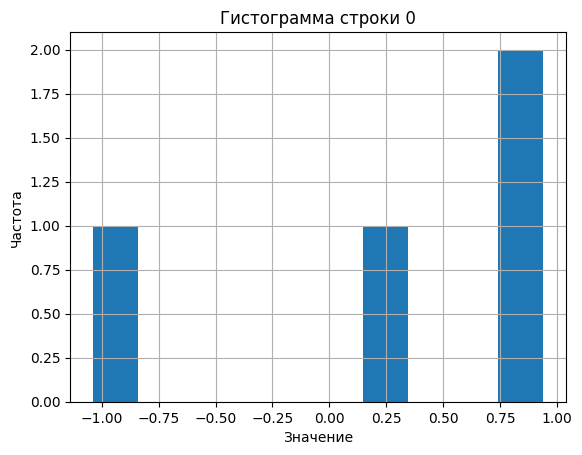

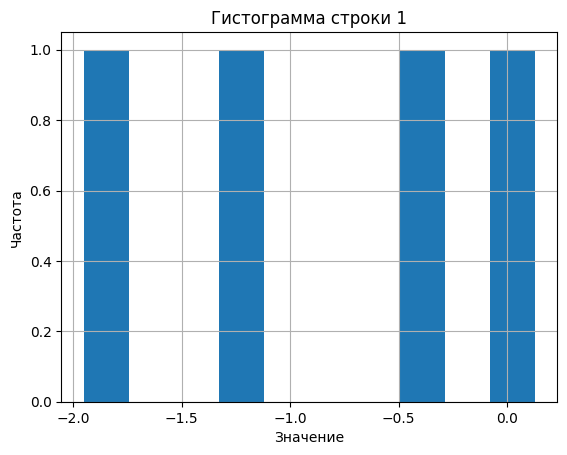

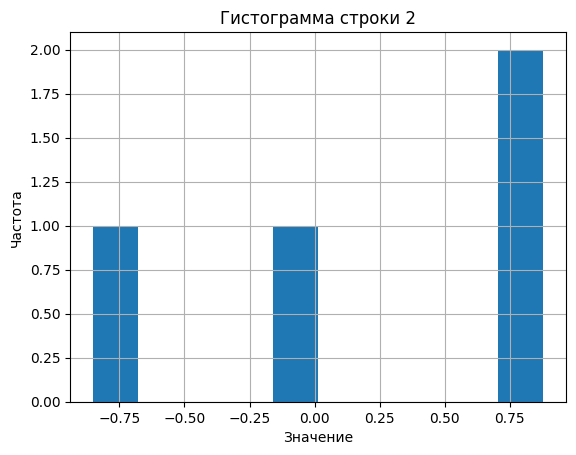

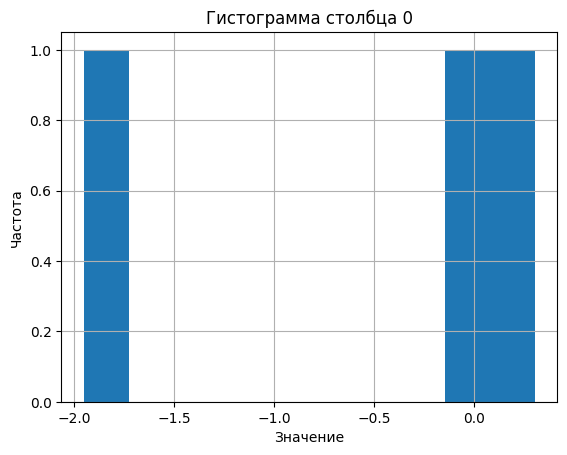

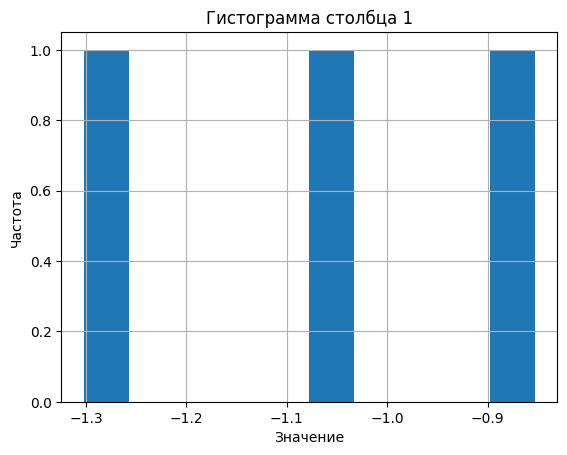

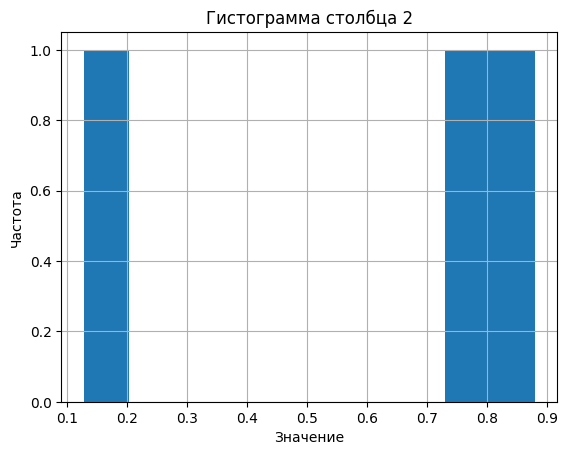

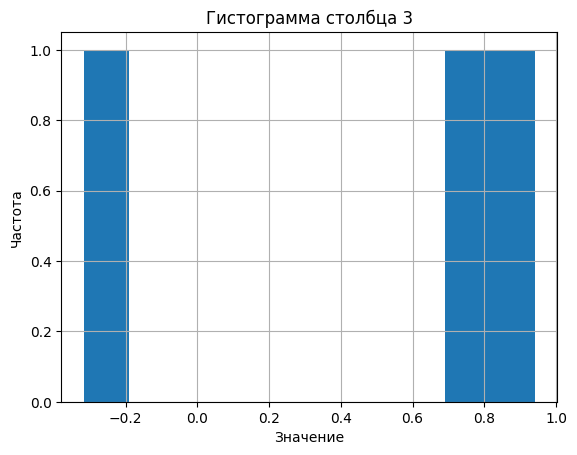

Матрица:
[[ 0.30471708 -1.03998411  0.7504512   0.94056472]
 [-1.95103519 -1.30217951  0.1278404  -0.31624259]
 [-0.01680116 -0.85304393  0.87939797  0.77779194]]

Мат. ожидание по строкам:
[ 0.23893722 -0.86040422  0.19683621]

Дисперсия по строкам:
[0.59847361 0.66434516 0.48782234]

Мат. ожидание по столбцам:
[-0.55437309 -1.06506918  0.58589652  0.46737135]

Дисперсия по столбцам:
[0.99256151 0.03393509 0.10767892 0.31144124]


In [15]:
M, row_means, row_vars, col_means, col_vars = analyze_matrix(3, 4, seed=42)

print("Матрица:")
print(M)

print("\nМат. ожидание по строкам:")
print(row_means)

print("\nДисперсия по строкам:")
print(row_vars)

print("\nМат. ожидание по столбцам:")
print(col_means)

print("\nДисперсия по столбцам:")
print(col_vars)

In [16]:
# Тест 1. Проверка размеров
M, row_means, row_vars, col_means, col_vars = analyze_matrix(3, 4, seed=42, show_plots=False)

assert M.shape == (3, 4)
assert row_means.shape == (3,)
assert row_vars.shape == (3,)
assert col_means.shape == (4,)
assert col_vars.shape == (4,)
print("Тест 1 пройден")


# Тест 2. Проверка вычисления средних по строкам
assert np.allclose(row_means, M.mean(axis=1))
print("Тест 2 пройден")


# Тест 3. Проверка вычисления дисперсий по строкам
assert np.allclose(row_vars, M.var(axis=1))
print("Тест 3 пройден")


# Тест 4. Проверка вычисления средних по столбцам
assert np.allclose(col_means, M.mean(axis=0))
print("Тест 4 пройден")


# Тест 5. Проверка вычисления дисперсий по столбцам
assert np.allclose(col_vars, M.var(axis=0))
print("Тест 5 пройден")


print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Тест 5 пройден
Все тесты пройдены успешно


<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [17]:
def chess(m, n, a, b):
    result = np.empty((m, n), dtype=type(a))

    for i in range(m):
        for j in range(n):
            if (i + j) % 2 == 0:
                result[i, j] = a
            else:
                result[i, j] = b

    return result

In [18]:
# Тест 1. Квадратная матрица 3x3
result = chess(3, 3, 1, 0)
expected = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

assert np.array_equal(result, expected)
print("Тест 1 пройден")


# Тест 2. Прямоугольная матрица 2x4
result = chess(2, 4, 5, 9)
expected = np.array([
    [5, 9, 5, 9],
    [9, 5, 9, 5]
])

assert np.array_equal(result, expected)
print("Тест 2 пройден")


# Тест 3. Один элемент
result = chess(1, 1, 7, 3)
expected = np.array([[7]])

assert np.array_equal(result, expected)
print("Тест 3 пройден")


# Тест 4. Один столбец
result = chess(4, 1, 2, 8)
expected = np.array([[2],[8],[2],[8]])

assert np.array_equal(result, expected)
print("Тест 4 пройден")


# Тест 5. Строковые значения
result = chess(2, 3, "A", "B")
expected = np.array([
    ["A", "B", "A"],
    ["B", "A", "B"]
])

assert np.array_equal(result, expected)
print("Тест 5 пройден")


print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Тест 5 пройден
Все тесты пройдены успешно


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [20]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    image = np.full((m, n, 3), background_color, dtype=np.uint8)

    # a — ширина по горизонтали, b — высота по вертикали
    x_start = max((n - a) // 2, 0)
    x_end = min(x_start + a, n)

    y_start = max((m - b) // 2, 0)
    y_end = min(y_start + b, m)

    image[y_start:y_end, x_start:x_end] = rectangle_color
    return image


def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    image = np.full((m, n, 3), background_color, dtype=np.uint8)

    # центр изображения
    x0 = (n - 1) / 2
    y0 = (m - 1) / 2

    yy, xx = np.ogrid[:m, :n]

    # a — полуось по x, b — полуось по y
    mask = ((xx - x0) ** 2) / (a ** 2) + ((yy - y0) ** 2) / (b ** 2) <= 1

    image[mask] = ellipse_color
    return image

In [21]:
# цвета
RED = (255, 0, 0)
WHITE = (255, 255, 255)
BLUE = (0, 0, 255)
BLACK = (0, 0, 0)

# Тесты для прямоугольника

img = draw_rectangle(4, 2, 6, 8, RED, WHITE)

# 1. Проверка размера изображения
assert img.shape == (6, 8, 3)
print("Тест 1 пройден")

# 2. Проверка цвета фона в углу
assert np.array_equal(img[0, 0], WHITE)
print("Тест 2 пройден")

# 3. Проверка цвета внутри прямоугольника
# для m=6, n=8, a=4, b=2 прямоугольник по центру:
# y: 2..3, x: 2..5
assert np.array_equal(img[2, 2], RED)
assert np.array_equal(img[3, 5], RED)
print("Тест 3 пройден")

# 4. Проверка, что вне прямоугольника фон
assert np.array_equal(img[1, 1], WHITE)
assert np.array_equal(img[5, 7], WHITE)
print("Тест 4 пройден")


# Тесты для эллипса

img2 = draw_ellipse(2, 1, 5, 7, BLUE, BLACK)

# 5. Проверка размера изображения
assert img2.shape == (5, 7, 3)
print("Тест 5 пройден")

# 6. Центр эллипса должен быть закрашен
center_y = (5 - 1) // 2
center_x = (7 - 1) // 2
assert np.array_equal(img2[center_y, center_x], BLUE)
print("Тест 6 пройден")

# 7. Угол изображения должен остаться фоном
assert np.array_equal(img2[0, 0], BLACK)
assert np.array_equal(img2[4, 6], BLACK)
print("Тест 7 пройден")

# 8. Проверка, что хотя бы часть изображения закрашена
blue_pixels = np.sum(np.all(img2 == BLUE, axis=2))
assert blue_pixels > 0
print("Тест 8 пройден")

print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Тест 5 пройден
Тест 6 пройден
Тест 7 пройден
Тест 8 пройден
Все тесты пройдены успешно


<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [22]:
def analyze_series(series, p):
    series = np.asarray(series, dtype=float)

    mean = series.mean()
    var = series.var()
    std = series.std()

    local_max = []
    local_min = []

    for i in range(1, len(series) - 1):
        if series[i] > series[i - 1] and series[i] > series[i + 1]:
            local_max.append((i, series[i]))
        if series[i] < series[i - 1] and series[i] < series[i + 1]:
            local_min.append((i, series[i]))

    moving_avg = np.array([
        series[i:i + p].mean() for i in range(len(series) - p + 1)
    ])

    return {
        "mean": mean,
        "var": var,
        "std": std,
        "local_max": local_max,
        "local_min": local_min,
        "moving_avg": moving_avg
    }

In [23]:
# тестовый ряд
series = np.array([1, 3, 2, 5, 4, 6, 3])
p = 3

result = analyze_series(series, p)

# Тест 1. Матожидание
assert np.isclose(result["mean"], np.mean(series))
print("Тест 1 пройден")

# Тест 2. Дисперсия
assert np.isclose(result["var"], np.var(series))
print("Тест 2 пройден")

# Тест 3. СКО
assert np.isclose(result["std"], np.std(series))
print("Тест 3 пройден")

# Тест 4. Локальные максимумы
expected_max = [(1, 3.0), (3, 5.0), (5, 6.0)]
assert result["local_max"] == expected_max
print("Тест 4 пройден")

# Тест 5. Локальные минимумы
expected_min = [(2, 2.0), (4, 4.0)]
assert result["local_min"] == expected_min
print("Тест 5 пройден")

# Тест 6. Скользящее среднее
expected_ma = np.array([
    (1 + 3 + 2) / 3,
    (3 + 2 + 5) / 3,
    (2 + 5 + 4) / 3,
    (5 + 4 + 6) / 3,
    (4 + 6 + 3) / 3
])
assert np.allclose(result["moving_avg"], expected_ma)
print("Тест 6 пройден")

print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Тест 5 пройден
Тест 6 пройден
Все тесты пройдены успешно


<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [24]:
def one_hot(labels):
    labels = np.asarray(labels, dtype=int)
    num_classes = labels.max() + 1

    result = np.zeros((len(labels), num_classes), dtype=int)
    result[np.arange(len(labels)), labels] = 1

    return result

In [25]:
# Тест 1. Пример из условия
labels = np.array([0, 2, 3, 0])
expected = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0]
])

result = one_hot(labels)
assert np.array_equal(result, expected)
print("Тест 1 пройден")


# Тест 2. Последовательные классы
labels = np.array([0, 1, 2])
expected = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

result = one_hot(labels)
assert np.array_equal(result, expected)
print("Тест 2 пройден")


# Тест 3. Повторяющиеся метки
labels = np.array([1, 1, 1])
expected = np.array([
    [0, 1],
    [0, 1],
    [0, 1]
])

result = one_hot(labels)
assert np.array_equal(result, expected)
print("Тест 3 пройден")


# Тест 4. Один элемент
labels = np.array([2])
expected = np.array([
    [0, 0, 1]
])

result = one_hot(labels)
assert np.array_equal(result, expected)
print("Тест 4 пройден")


print("Все тесты пройдены успешно")

Тест 1 пройден
Тест 2 пройден
Тест 3 пройден
Тест 4 пройден
Все тесты пройдены успешно
